# 1) (Manual Collaborative Filtering)
| User   | Item 1 | Item 2 | Item 3 | Item 4 | Item 5 |
|--------|--------|--------|--------|--------|--------|
| User 1 | 3      |        | 2      | 3      | 3      |
| User 2 | 4      | 3      | 4      | 3      |        |
| User 3 | 3      | 2      | 1      | 4      | 4      |
| User 4 |        | 5      | 4      | 3      | 1      |
| User a | 5      |        | 3      | 4      | ?      |


**Item-base similarity** 


$$
\begin{align*}
sim(i_5,i_4) 
&= \frac{(3-2.75)*(3-2.75) + (4-2.8)*(4-2.8)+(1-3.25)*(3-3.25)}{\sqrt(6.5645)*\sqrt(\sum_{U_1, U_3, U_4}(r_{u,j}-\bar{r_u})^2)} \\
&= \frac{0.25*0.25 + 1.2*1.2+-2.25*-0.25}{\sqrt(6.5645)*\sqrt(0.25^2 + 1.2^2 + 0.25^2)} \\
&= \frac{2.065}{\sqrt(6.5645)*\sqrt(1.565)} \\
&=0.644261320970367 
\end{align*}
$$

$$
\begin{align*}
sim(i_5,i_3) 
&= \frac{\sum_{U_1, U_3, U_4}(r_{u,i}-\bar{r_u})*(r_{u,j}-\bar{r_u})}{\sqrt(\sum_{U_1, U_3, U_4}(r_{u,i}-\bar{r_u})^2)*\sqrt(\sum_{U_1, U_3, U_4}(r_{u,j}-\bar{r_u})^2)} \\
&= \frac{(3-2.75)*(2-2.75) + (4-2.8) *(1-2.8) + (1-3.25)*(4-3.25)}{\sqrt(\sum_{U_1, U_3, U_4}(r_{u,i}-\bar{r_u})^2)*\sqrt(\sum_{U_1, U_3, U_4}(r_{u,j}-\bar{r_u})^2)} \\
&= \frac{(0.25)*(-0.75) + (1.2) *(-1.8) + (-2.25)*(0.75)}{\sqrt(0.25^2 + 1.2^2 + 2.25^2)*\sqrt(0.75^2 + 1.8^2 + 0.75^2)} \\
&= \frac{-4.035}{\sqrt(6.5645)*\sqrt(4.365)} \\
&=-0.7537903766957521
\end{align*}
$$

$$
\begin{align*}
sim(i_5,i_2) 
&= \frac{\sum_{U_4, U_3}(r_{u,i}-\bar{r_u})*(r_{u,j}-\bar{r_u})}{\sqrt(\sum_{U_4, U_3}(r_{u,i}-\bar{r_u})^2)*\sqrt(\sum_{U_4, U_3}(r_{u,j}-\bar{r_u})^2)} \\
&= \frac{(1-3.25)*(5-3.25) +(4-2.8)*(2-2.8)}{\sqrt(((1-3.25)^2+(4-2.8))^2)*\sqrt(((5-3.25)^2+(2-2.8)^2))} \\
&= \frac{(-2.25)*1.75 +1.2*-0.8}{\sqrt((-2.25)^2+(1.2)^2)*\sqrt((1.75)^2+ (-0.8)^2)} \\
&= \frac{-4.8975}{\sqrt(6.5025)*\sqrt(3.7025)} \\
&=-0.9981291303487856
\end{align*}
$$


$$
\begin{align*}
sim(i_5,i_1) 
&= \frac{\sum_{U_1, U_3}(r_{u,i}-\bar{r_u})*(r_{u,j}-\bar{r_u})}{\sqrt(\sum_{U_1, U_3}(r_{u,i}-\bar{r_u})^2)*\sqrt(\sum_{U_1, U_3}(r_{u,j}-\bar{r_u})^2)} \\
&=\frac{(3-2.75)*(3-2.75) + (3-2.8)*(4-2.8)}{\sqrt((3-2.75)^2 + (3-2.8)^2) * \sqrt((3-2.75)^2 + (4-2.8)^2)} \\
&=\frac{0.25^2 + 0.2*1.2}{\sqrt((0.25)^2 + 0.2^2) * \sqrt(0.25^2 + 1.2^2)} \\
&=\frac{0.3052}{\sqrt(0.1025) * \sqrt(1.5025)} \\
&=0.77771
\end{align*} $$

Next we are taking the most similar (k=2) items i4 and i1 and calculate the scoring

$$
\begin{align*}
\hat{r}_{u,i} 
&= 
\frac{\sum_{j \in N(i)} sim(i,j) \cdot r_{u,j}}
{\sum_{j \in N(i)} |sim(i,j)|} \\
&= \frac{0.77771 * 5 +0.644*4}{|0.77771| + |0.644|} \\
&= 4.547
\end{align*}
$$

Therefore this is definitely a recommendation

# 2) (Neighborhood-based CF with LensKit)

In [1]:
from lenskit.data import load_movielens
ml100k = load_movielens("./ml-100k")
print(ml100k.interaction_table(format="pandas", original_ids=True).head())


c:\Users\jonas\AppData\Local\Programs\Python\Python313\Lib\site-packages\lenskit\data\movielens.py:143: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  return pd.read_csv(


   user_id  item_id  rating           timestamp
0        1        1     5.0 1997-09-22 22:02:38
1        1        2     3.0 1997-10-15 05:26:11
2        1        3     4.0 1997-11-03 07:42:40
3        1        4     3.0 1997-10-15 05:25:19
4        1        5     3.0 1998-03-13 01:15:12


c:\Users\jonas\AppData\Local\Programs\Python\Python313\Lib\site-packages\lenskit\data\movielens.py:157: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  return pd.read_csv(


## a) 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lenskit.data import ItemListCollection, UserIDKey, load_movielens
from lenskit.knn import ItemKNNScorer, UserKNNScorer
from lenskit.metrics import NDCG, MeasurementCollector
from lenskit.pipeline import topn_pipeline
from lenskit.splitting import SampleFrac, crossfold_users
from lenskit.operations import recommend
from lenskit.data import RecQuery
from lenskit.basic import BiasScorer, PopScorer

# item and user based recommendation 
item_cf_scorer = ItemKNNScorer(k=20)
user_cf_scorer = UserKNNScorer(k=20)

pipeline_item = topn_pipeline(item_cf_scorer)
pipeline_user = topn_pipeline(user_cf_scorer)

pipeline_item.train(ml100k)
pipeline_user.train(ml100k)

#baselines 
bias_scorer = BiasScorer()
pop_scorer = PopScorer()

pipeline_bias = topn_pipeline(bias_scorer)
pipeline_popular = topn_pipeline(pop_scorer)

user_id = 1
query = RecQuery(user_id=user_id)
recommendations_items = recommend(pipeline_item, query=query, n=5)
recommendations_users = recommend(pipeline_user, query=query, n=5) 
print("Recommendations based on items: ")
print(recommendations_items.to_df())
print("Recommendations based on users: ")
print(recommendations_users.to_df())


Recommendations based on items: 
   item_id  item_num     score  rank  nbr_counts
0      408       407  5.114226     1          20
1      963       962  5.002028     2          20
2      285       284  4.883401     3          20
3     1449      1448  4.882670     4          20
4     1398      1397  4.853101     5          20
Recommendations based on users: 
   item_id  item_num     score  rank
0      814       813  5.512810     1
1     1536      1535  5.314920     2
2     1467      1466  5.129309     3
3     1500      1499  5.114487     4
4     1599      1598  5.028545     5


## b) 

Start 5-Fold cross validation...
Training times: 
 {'ItemKNN': 13.513837575912476, 'UserKNN': 11.115755319595337, 'Bias': 5.32293963432312, 'Popular': 2.6628670692443848}
calculating metrics ...

--- ERROR MEASURES (RMSE, MAE) ---
             RMSE       MAE
model                      
ItemKNN  0.889093  0.727303
Bias     0.923023  0.760692
UserKNN  0.924966  0.755072

--- RANKING METRICS (Precision, Recall, F1 @10) ---
         Precision@10  Recall@10     F1@10
model                                     
Popular      0.185366   0.207651  0.192976
ItemKNN      0.041145   0.042090  0.041488
UserKNN      0.005090   0.005719  0.005296
Bias         0.000106   0.000106  0.000106


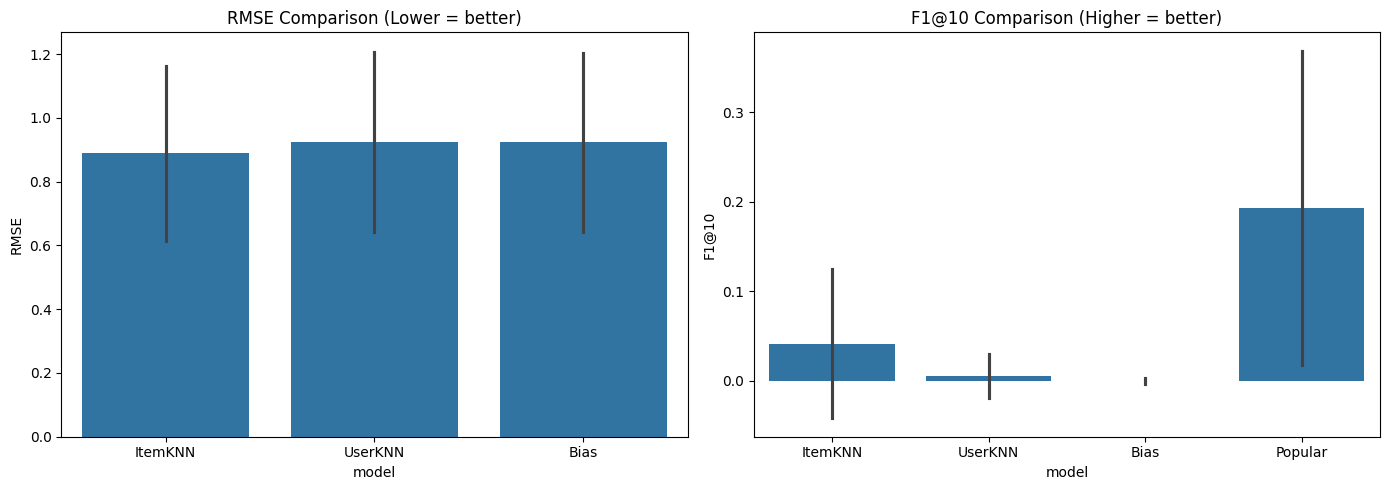

In [3]:
from lenskit.als import BiasedMFScorer
from lenskit.batch import recommend, predict 
from lenskit.data import ItemListCollection, UserIDKey, load_movielens
from lenskit.knn import ItemKNNScorer
from lenskit.metrics import RMSE, MAE, Recall, Precision, MeasurementCollector
from lenskit.pipeline import topn_pipeline, predict_pipeline
from lenskit.splitting import SampleFrac, crossfold_users
import time

pipelines_topn = {
    "ItemKNN": topn_pipeline(item_cf_scorer),
    "UserKNN": topn_pipeline(user_cf_scorer),
    "Bias": topn_pipeline(bias_scorer),
    "Popular": topn_pipeline(pop_scorer)
}

pipelines_pred = {
    "ItemKNN": predict_pipeline(item_cf_scorer),
    "UserKNN": predict_pipeline(user_cf_scorer),
    "Bias": predict_pipeline(bias_scorer),
    # doesnt work for popular scorer 
}

all_test = ItemListCollection(UserIDKey)

all_recs = {model: ItemListCollection(UserIDKey) for model in pipelines_topn.keys()}
all_preds = {model: ItemListCollection(UserIDKey) for model in pipelines_pred.keys()}

K_RECOMMENDATIONS = 10 

print("Start 5-Fold cross validation...")
times = {}
for split in crossfold_users(ml100k, 5, SampleFrac(0.2)):
    all_test.add_from(split.test)
    test_users = list(split.test.keys()) 
    
    for model_name, pipeline in pipelines_topn.items():
        
        start_time = time.time() 
        fit_pipe = pipeline.clone()
        fit_pipe.train(split.train)
        
        recs = recommend(fit_pipe, test_users, K_RECOMMENDATIONS)
        all_recs[model_name].add_from(recs)
        
        if model_name in pipelines_pred:
            fit_pred = pipelines_pred[model_name].clone()
            fit_pred.train(split.train)
            
            preds = predict(fit_pred, split.test)
            all_preds[model_name].add_from(preds)
        if model_name in times.keys(): 
            times[model_name]+= time.time() - start_time
        else: 
            times[model_name] = time.time() - start_time

print("Training times: \n", times)
print("calculating metrics ...")


mc_ranking = MeasurementCollector()
mc_ranking.add_metric(Precision(n=K_RECOMMENDATIONS))
mc_ranking.add_metric(Recall(n=K_RECOMMENDATIONS))

mc_error = MeasurementCollector()
mc_error.add_metric(RMSE())
mc_error.add_metric(MAE())

ranking_metrics = []
error_metrics = []

for model_name in pipelines_topn.keys():
    _, r_metrics = mc_ranking.measure_run(all_recs[model_name], all_test)
    r_metrics["model"] = model_name
    
    # divsion by 0 problem 
    r_metrics["F1@10"] = 2 * (r_metrics["Precision@10"] * r_metrics["Recall@10"]) / (r_metrics["Precision@10"] + r_metrics["Recall@10"] + 1e-9)
    ranking_metrics.append(r_metrics)
    
    if model_name in all_preds:
        _, e_metrics = mc_error.measure_run(all_preds[model_name], all_test)
        e_metrics["model"] = model_name
        error_metrics.append(e_metrics)

df_ranking = pd.concat(ranking_metrics)
df_error = pd.concat(error_metrics)

mean_ranking = df_ranking.groupby("model").mean()
mean_error = df_error.groupby("model").mean()

print("\n--- ERROR MEASURES (RMSE, MAE) ---")
print(mean_error[["RMSE", "MAE"]].sort_values(by="RMSE"))

print("\n--- RANKING METRICS (Precision, Recall, F1 @10) ---")
print(mean_ranking[["Precision@10", "Recall@10", "F1@10"]].sort_values(by="F1@10", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_error.reset_index(), x="model", y="RMSE", ax=axes[0], errorbar='sd')
axes[0].set_title('RMSE Comparison (Lower = better)')
axes[0].set_ylabel('RMSE')

sns.barplot(data=df_ranking.reset_index(), x="model", y="F1@10", ax=axes[1], errorbar='sd')
axes[1].set_title('F1@10 Comparison (Higher = better)')
axes[1].set_ylabel('F1@10')

plt.tight_layout()
plt.show()



In [4]:
num_users = ml100k.user_count
num_items = ml100k.item_count

try:
    num_ratings = ml100k.interaction_count
except AttributeError:
    num_ratings = len(ml100k.interactions().to_df())

print(f"Number ratings: {num_ratings}")
print(f"Number users: {num_users}")
print(f"Number films: {num_items}")
print("-" * 40)
print(f"User-Similarity matrix (UserKNN): {num_users} x {num_users}")
print(f"Item-Similarity matrix (ItemKNN): {num_items} x {num_items}")


Number ratings: 100000
Number users: 943
Number films: 1682
----------------------------------------
User-Similarity matrix (UserKNN): 943 x 943
Item-Similarity matrix (ItemKNN): 1682 x 1682


## discussion
**Baselines**  
The popular scorer just recomends the best rated movies (like a leaderboard). Because of this its not possible to use it to predict the rating of a film.
Because this is the only data-basis it takes into account. But we can use it to make recommendations and check if its in the top @k of a user. 

The Bias-Scorer does a prediction like that: $prediction = global + user bias + item bias$ 
For example if it wants to predict the rating a user will give for Star Wars, it takes the average how this film is rated e.g. 4 stars, it then adds if the user 
generally rates higher/lower ($\frac{1}{number films} * \sum_{all films} |r_{uf} - \hat{r_f}|$, difference between user rating and general) and then adds the item bias if this film is generally better rated than other films. 

**Error measures**  
RMSE (Root mean square error) is the root of the squared error between prediction and label. Big differences lead to big penalties. 
MAE (Mean absolute error) is the difference between prediction and label. Every difference (error) has the same cost. e.g. rating 100 movies wrong for 0.1 star = 10 penalties is the same as rating 99 correct and one of them completely wrong. 


| Modell  |     RMSE |      MAE |
| ------- | -------: | -------: |
| ItemKNN | 0.902891 | 0.737021 |
| UserKNN | 0.933704 | 0.759553 |
| Bias    | 0.934428 | 0.767403 |

As we can see the item scorer yields the best results, after that the user-based scorer follows and the bias scorer performs the worst. 
Because the bias scorer performs quite the same as the UserKNN it probably relys heavily on the internal use of its UserKNN part.   

From the MAE we can quite easily retreive a interpretable result, with a MAE of around 0.74 we know that the predictions are of by about this amount. 
This means a film which is rated at 3.4 stars we know that the average prediction is between [2.7; 4.1]. Which is not to bad but is not spot on either. 
I think for the rating prediction this is okay because from that you yould only recommend films which have a high predicted rating e.g. > 4.5 and if you mispredict that by 
0.7 it is still a 3.8 which is still a good film 

**Ranking Metrics** 
Here we have 
- precision (from the 10 recommendations how many are actually in the top 10) 
- recall (how many from the user top 10 where actually found) 
- f1@10 (harmonic mean between the two)


c

From the table we can once again see that the most-popular approach outperforms everything else by a lot. 
If we use this approach to recommend 10 films to the user. 19% will be actually in the top 10 of the user (=2) and it has 
found 21,5% from the user top 10 films. 

This is actually a usable approach because if from a list of 10 recommendations there are 2 films which will be in my favourite 10 films list, these 
are recommendations which are actually usefull for me. 

The next best approach ItemKnn with a precision of 4% means that if it recommends 10 films only 0.4 of them will be in my favourite list. (this means i have to reload the page 
to find a good one). This is not a good result, i would be unhappy with those recommendations. 
And for the other approaches the result get even worse. 



**Comparision Item-based & User-based** 
In comparision the item-based approach works better, both for the ranking metrics as well as the error measures. I think this is mostly because films keep their 
properties and their ratings are averaged over huge user groups which make the result quite stable. Users on the other hand are quite hard to predict. 
They change their taste, they have different moods or they share their account which completely changes their personality thus making them harder to predict. 
We had the following training times: 
- 'ItemKNN': 5.9364588260650635
- 'UserKNN': 4.017136096954346
this means we need 1.5 times the time to train the item based approach. 
This is because for the user matrix we need 943x943=889249  and for the item matrix 1682x1682=2829124. 

In conclusion i think its better to use the item-based approach, yes it needs more computation but i also think that items don't move as fast as the user base. This means we 
don't need to recompute the recommendations as often. 


**rating predictions vs ranking metrics** 
The ranking metrics are looking at all items (good predicted films as well as bad predicted films). They try to reproduce the exakt rating of a film. 
The ranking metrics are more focused on the real utility of the predictions it doesnt help to correctly identify the worst films to recommend for a user (but if the recommender is good at 
that the ranking metrics are favouring this) and only the best predicted films are relevant. 
Its also irrelevant if the algorithm correctly predicts the exakt rating as long as the relevant films are in the top 10. 


**Do they lead to the same conclusions** 
No absolutely not. 
With only using the ranking based metrics it could be that the algorithm correctly predicts 99% of the films but makes huge errors in the top 1% of films. Thus 
recommending the completely wrong films for the user. Therefore the ranking based metrics are more imporant to measure the real utility of the recommendations. 
Also we can see that the bias score has okaish results for the metric based evaluation because it predicts based on average ratings, this is mostly not completely wrong 
but on the other hand most of the films are rated quite average which results in it not being able to produce good recommendations which are in the top 10 of a user. 


## c) hyperparameter

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from lenskit.basic import BiasScorer, PopScorer
from lenskit.batch import recommend, predict 
from lenskit.data import ItemListCollection, UserIDKey, ItemList 
from lenskit.knn import ItemKNNScorer, UserKNNScorer
from lenskit.metrics import RMSE, MAE, Recall, Precision, MeasurementCollector
from lenskit.pipeline import topn_pipeline, predict_pipeline
from lenskit.splitting import SampleFrac, crossfold_users

bias_scorer = BiasScorer()
pop_scorer = PopScorer()

pipelines_topn = {
    "Bias": topn_pipeline(bias_scorer),
    "Popular": topn_pipeline(pop_scorer)
}

pipelines_pred = {
    "Bias": predict_pipeline(bias_scorer),
}

# Grid search 
for k in [10, 25, 50]:
    for min_n in [1, 5]:
        
        i_scorer = ItemKNNScorer(k=k, min_nbrs=min_n)
        u_scorer = UserKNNScorer(k=k, min_nbrs=min_n)
        
        # WICHTIG: Den Key dynamisch mit k UND min_n benennen!
        name_i = f"ItemKNN (k={k}, min={min_n})"
        name_u = f"UserKNN (k={k}, min={min_n})"
        
        # In die Dictionaries einfügen
        pipelines_topn[name_i] = topn_pipeline(i_scorer)
        pipelines_topn[name_u] = topn_pipeline(u_scorer)
        
        pipelines_pred[name_i] = predict_pipeline(i_scorer)
        pipelines_pred[name_u] = predict_pipeline(u_scorer)

all_test = ItemListCollection(UserIDKey)
all_recs = {model: ItemListCollection(UserIDKey) for model in pipelines_topn.keys()}
all_preds = {model: ItemListCollection(UserIDKey) for model in pipelines_pred.keys()}

K_RECOMMENDATIONS = 10 

print("Start 5-Fold cross validation...")
times = {model: 0.0 for model in pipelines_topn.keys()}

for split in crossfold_users(ml100k, 5, SampleFrac(0.2)):
    # 1. Testdaten komplett einsammeln (gefiltert wird später)
    all_test.add_from(split.test)
    test_users = list(split.test.keys()) 
    
    # 2. Modelle trainieren und vorhersagen
    for model_name, pipeline in pipelines_topn.items():
        start_time = time.time() 
        
        fit_pipe = pipeline.clone()
        fit_pipe.train(split.train)
        recs = recommend(fit_pipe, test_users, K_RECOMMENDATIONS)
        all_recs[model_name].add_from(recs)
        
        # Rating Predict
        if model_name in pipelines_pred:
            fit_pred = pipelines_pred[model_name].clone()
            fit_pred.train(split.train)
            preds = predict(fit_pred, split.test)
            all_preds[model_name].add_from(preds)
            
        times[model_name] += (time.time() - start_time)
print("Training times: \n", times)

Start 5-Fold cross validation...
Training times: 
 {'Bias': 5.310858488082886, 'Popular': 2.860429525375366, 'ItemKNN (k=10, min=1)': 13.254472255706787, 'UserKNN (k=10, min=1)': 10.664605617523193, 'ItemKNN (k=10, min=5)': 12.93361210823059, 'UserKNN (k=10, min=5)': 10.009356498718262, 'ItemKNN (k=25, min=1)': 13.01474404335022, 'UserKNN (k=25, min=1)': 10.660403490066528, 'ItemKNN (k=25, min=5)': 13.53895878791809, 'UserKNN (k=25, min=5)': 10.494308233261108, 'ItemKNN (k=50, min=1)': 13.384653329849243, 'UserKNN (k=50, min=1)': 10.353904247283936, 'ItemKNN (k=50, min=5)': 12.94323205947876, 'UserKNN (k=50, min=5)': 11.772042989730835}


Calculating metrics ...

--- ERROR MEASURES (RMSE, MAE) ---
                           RMSE       MAE
model                                    
ItemKNN (k=25, min=1)  0.901915  0.737969
ItemKNN (k=25, min=5)  0.902211  0.738213
ItemKNN (k=50, min=1)  0.903820  0.740804
ItemKNN (k=50, min=5)  0.904116  0.741048
ItemKNN (k=10, min=1)  0.905865  0.738102
ItemKNN (k=10, min=5)  0.906165  0.738346
UserKNN (k=50, min=1)  0.927735  0.758691
UserKNN (k=25, min=1)  0.929627  0.759490
UserKNN (k=50, min=5)  0.929643  0.760762
UserKNN (k=25, min=5)  0.931564  0.761561
Bias                   0.934228  0.771887
UserKNN (k=10, min=1)  0.945668  0.771642
UserKNN (k=10, min=5)  0.947643  0.773713

--- RANKING METRICS (Precision, Recall, F1 @10) ---
                       Precision@10  Recall@10     F1@10
model                                                   
Popular                    0.193319   0.216977  0.201295
UserKNN (k=25, min=5)      0.080276   0.085123  0.081947
UserKNN (k=10, min=5)      0.

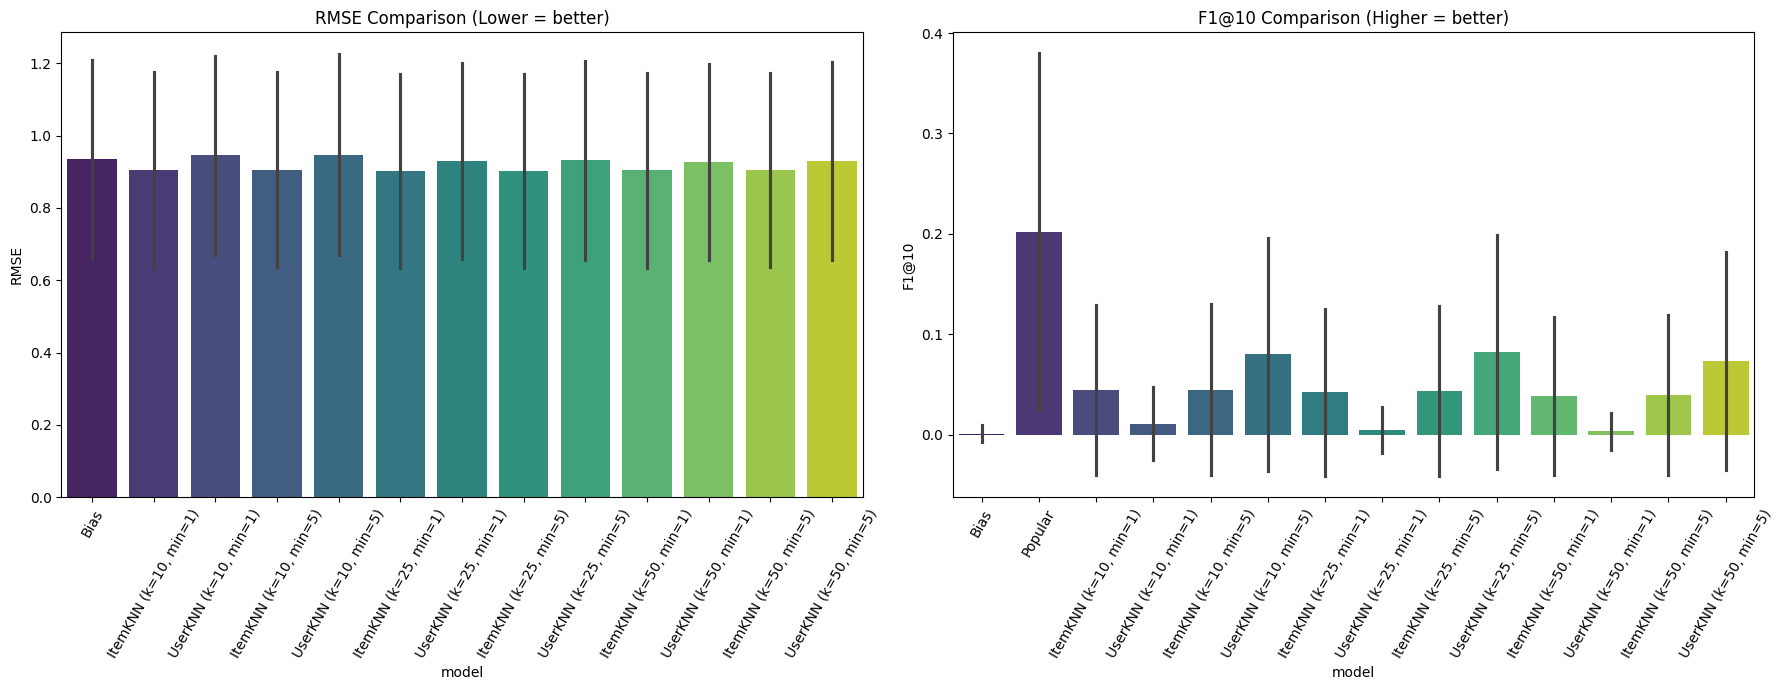

In [6]:


print("Calculating metrics ...")
mc_ranking = MeasurementCollector()
mc_ranking.add_metric(Precision(n=K_RECOMMENDATIONS))
mc_ranking.add_metric(Recall(n=K_RECOMMENDATIONS))

mc_error = MeasurementCollector()
mc_error.add_metric(RMSE())
mc_error.add_metric(MAE())

ranking_metrics = []
error_metrics = []

for model_name in pipelines_topn.keys():
    
    _, r_metrics = mc_ranking.measure_run(all_recs[model_name], all_test)
    r_metrics["model"] = model_name
    r_metrics["F1@10"] = 2 * (r_metrics["Precision@10"] * r_metrics["Recall@10"]) / (r_metrics["Precision@10"] + r_metrics["Recall@10"] + 1e-9)
    ranking_metrics.append(r_metrics)
    
    if model_name in all_preds:
        _, e_metrics = mc_error.measure_run(all_preds[model_name], all_test)
        e_metrics["model"] = model_name
        error_metrics.append(e_metrics)

df_ranking = pd.concat(ranking_metrics)
df_error = pd.concat(error_metrics)

mean_ranking = df_ranking.groupby("model").mean()
mean_error = df_error.groupby("model").mean()

print("\n--- ERROR MEASURES (RMSE, MAE) ---")
print(mean_error[["RMSE", "MAE"]].sort_values(by="RMSE"))

print("\n--- RANKING METRICS (Precision, Recall, F1 @10) ---")
print(mean_ranking[["Precision@10", "Recall@10", "F1@10"]].sort_values(by="F1@10", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df_error.reset_index(), x="model", y="RMSE", hue="model", ax=axes[0], errorbar='sd', palette="viridis", legend=False)
axes[0].set_title('RMSE Comparison (Lower = better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=60)

sns.barplot(data=df_ranking.reset_index(), x="model", y="F1@10", hue="model", ax=axes[1], errorbar='sd', palette="viridis", legend=False)
axes[1].set_title('F1@10 Comparison (Higher = better)')
axes[1].set_ylabel('F1@10')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

## discussion 
We have changed two parameters: 
- k: At how many neighbours does the recommender look
- min_nbrs (minimal neighbours) if their are not enough neighbours than the model doesn't do a prediction and it uses the global prediction
In the error measures the differences aren't huge. The best result is achieved by setting k=10 and min_nbrs=5. This means we want to have more than 5 neighbours or we 
revert back to the global. I think this parameter tends to get as big as possible because then the better global prediction is used. 
And a neighbourhood of 10 is quite small. With that only the best matching films/users are used for the recommendation.

In the ranking metrics the results are bigger. Here we also see that the minimum amount of neighbours should be as high as possible but the choice of which k parameter to use 
is not so clear. Here k=25 yields the best results. 


## d) implicit

In [7]:
from lenskit.data import Dataset, ItemListCollection, UserIDKey, from_interactions_df
from lenskit.knn import ItemKNNScorer, UserKNNScorer
from lenskit.pipeline import topn_pipeline
from lenskit.batch import recommend
from lenskit.splitting import crossfold_users, SampleFrac
from lenskit.metrics import Precision, Recall, MeasurementCollector
import pandas as pd
import time

print("Transforming explicit ratings to implicit feedback...")
df_interactions = ml100k.interaction_matrix(format='pandas', field='rating')

rating_col = 'rating' if 'rating' in df_interactions.columns else 'value'

df_implicit = df_interactions[df_interactions[rating_col] > 3].copy()

implicit_dataset = from_interactions_df(
    df_implicit, 
    user_col='user_num', 
    item_col='item_num', 
    rating_col=rating_col
)

pipelines_implicit = {
    "ItemKNN (Implicit)": topn_pipeline(ItemKNNScorer(k=20, min_nbrs=1, feedback='implicit')),
    "UserKNN (Implicit)": topn_pipeline(UserKNNScorer(k=20, min_nbrs=1, feedback='implicit'))
}

all_test_implicit = ItemListCollection(UserIDKey)
all_recs_implicit = {model: ItemListCollection(UserIDKey) for model in pipelines_implicit.keys()}

K_RECOMMENDATIONS = 10

print("Start Cross-Validation on Implicit Data...")
for split in crossfold_users(implicit_dataset, 5, SampleFrac(0.2)):
    all_test_implicit.add_from(split.test)
    test_users = list(split.test.keys())
    
    for model_name, pipeline in pipelines_implicit.items():
        fit_pipe = pipeline.clone()
        fit_pipe.train(split.train)
        
        recs = recommend(fit_pipe, test_users, K_RECOMMENDATIONS)
        all_recs_implicit[model_name].add_from(recs)

print("Calculating Ranking Metrics...")

mc_implicit = MeasurementCollector()
mc_implicit.add_metric(Precision(n=K_RECOMMENDATIONS))
mc_implicit.add_metric(Recall(n=K_RECOMMENDATIONS))

ranking_metrics_implicit = []

for model_name in pipelines_implicit.keys():
    _, r_metrics = mc_implicit.measure_run(all_recs_implicit[model_name], all_test_implicit)
    r_metrics["model"] = model_name
    r_metrics["F1@10"] = 2 * (r_metrics["Precision@10"] * r_metrics["Recall@10"]) / (r_metrics["Precision@10"] + r_metrics["Recall@10"] + 1e-9)
    ranking_metrics_implicit.append(r_metrics)

df_ranking_implicit = pd.concat(ranking_metrics_implicit)
mean_ranking_implicit = df_ranking_implicit.groupby("model").mean()

print("\n--- IMPLICIT RANKING METRICS (Precision, Recall, F1 @10) ---")
print(mean_ranking_implicit[["Precision@10", "Recall@10", "F1@10"]].sort_values(by="F1@10", ascending=False))

Transforming explicit ratings to implicit feedback...
Start Cross-Validation on Implicit Data...
Calculating Ranking Metrics...

--- IMPLICIT RANKING METRICS (Precision, Recall, F1 @10) ---
                    Precision@10  Recall@10     F1@10
model                                                
UserKNN (Implicit)      0.216242   0.314854  0.240699
ItemKNN (Implicit)      0.174204   0.261476  0.195417


## discussion 
we can compare the new results from the implicit ranking (implicit >3): 
| Modell             | Precision@10 | Recall@10 |    F1@10 |
| ------------------ | -----------: | --------: | -------: |
| UserKNN (Implicit) |     0.210828 |  0.309925 | 0.235021 |
| ItemKNN (Implicit) |     0.171338 |  0.257184 | 0.192019 |



with the old results (explicit feedback 1-5): 
| Modell  | Precision@10 | Recall@10 |    F1@10 |
| ------- | -----------: | --------: | -------: |
| Popular |     0.193107 |  0.215806 | 0.200815 |
| ItemKNN |     0.040827 |  0.041703 | 0.041132 |
| UserKNN |     0.007635 |  0.007953 | 0.007741 |
| Bias    |     0.000424 |  0.000424 | 0.000424 |

We have had a huge increase in performance, now we can see that the UserKNN even outperforms the most popular approach. And also the ItemKNN can almost keep up with the most-popular approach. 

The big advantage is that we don't bother thinking about the films with bad expectations. Everything with bad ratings is just discarded and we just think which of the good films are the best. 
